In [1]:
!pip install -q --upgrade kaggle

In [2]:
import os
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_PASSWORD"] = userdata.get("KAGGLE_PASSWORD")

print("Kaggle credentials loaded successfully.")

Kaggle credentials loaded successfully.


In [3]:
!mkdir -p /content/data
!kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset -p /content/data

Dataset URL: https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset
License(s): other
microsoft-catsvsdogs-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
import zipfile
import os

zip_path = "/content/data/microsoft-catsvsdogs-dataset.zip"
extract_path = "/content/data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [5]:
base_dir = "/content/data/PetImages"

print("Available folders:", os.listdir(base_dir))
print("Cat images:", len(os.listdir(os.path.join(base_dir, "Cat"))))
print("Dog images:", len(os.listdir(os.path.join(base_dir, "Dog"))))

Available folders: ['Dog', 'Cat']
Cat images: 12501
Dog images: 12501


In [6]:
from PIL import Image

classes = ["Cat", "Dog"]
removed = 0

for class_name in classes:
    folder_path = os.path.join(base_dir, class_name)

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except Exception:
            os.remove(img_path)
            removed += 1

print("Corrupted images removed:", removed)

Corrupted images removed: 4


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 150
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    # Overfitting reduction through augmentation
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    base_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    base_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

print("Class labels:", train_data.class_indices)

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.
Class labels: {'Cat': 0, 'Dog': 1}


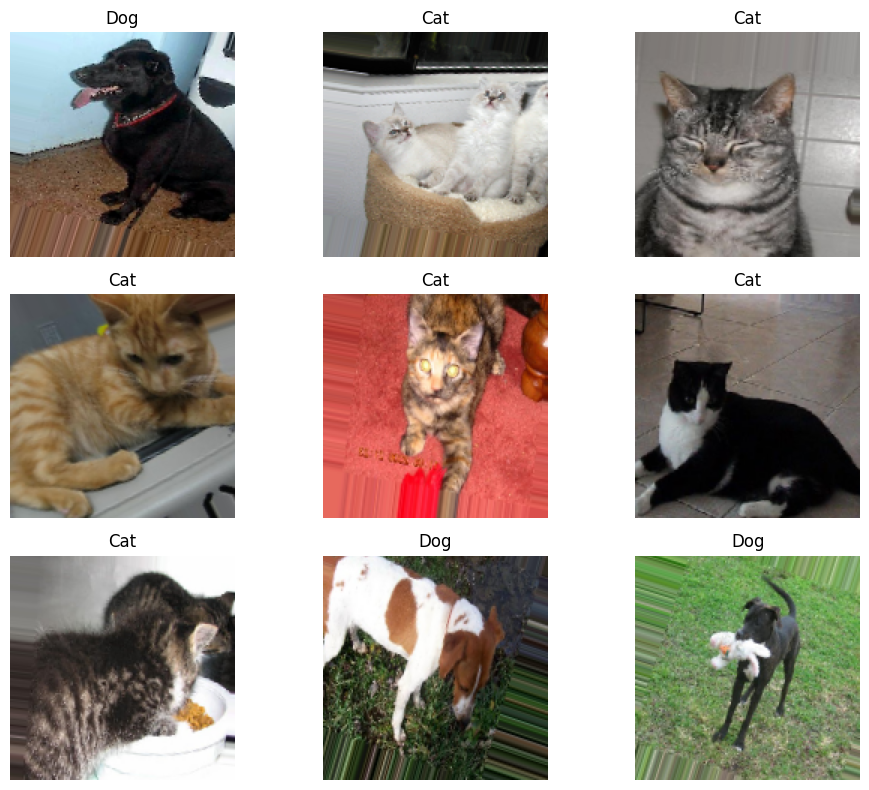

In [8]:
import matplotlib.pyplot as plt

images, labels = next(train_data)

plt.figure(figsize=(10, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title("Dog" if labels[i] == 1 else "Cat")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.regularizers import l2

model = Sequential([
    Conv2D(
        32, (3, 3), activation="relu", padding="same",
        kernel_regularizer=l2(0.001),
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    ),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    Conv2D(
        64, (3, 3), activation="relu", padding="same",
        kernel_regularizer=l2(0.001)
    ),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.30),

    Conv2D(
        128, (3, 3), activation="relu", padding="same",
        kernel_regularizer=l2(0.001)
    ),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.35),

    Conv2D(
        256, (3, 3), activation="relu", padding="same",
        kernel_regularizer=l2(0.001)
    ),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.40),

    GlobalAveragePooling2D(),

    Dense(128, activation="relu", kernel_regularizer=l2(0.001)),
    Dropout(0.50),

    Dense(1, activation="sigmoid")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,361 (1.61 MB)

 Trainable params: 422,401 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [10]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7
    ),

    ModelCheckpoint(
        "/content/best_cat_dog_basic_cnn_overfitting_solution.h5",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    )
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
621/625 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.5788 - loss: 1.1624

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.5789 - loss: 1.1621

625/625 ━━━━━━━━━━━━━━━━━━━━ 164s 241ms/step - accuracy: 0.5954 - loss: 1.1217 - val_accuracy: 0.6261 - val_loss: 1.0767 - learning_rate: 1.0000e-04
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.6284 - loss: 1.0559

625/625 ━━━━━━━━━━━━━━━━━━━━ 147s 236ms/step - accuracy: 0.6357 - loss: 1.0402 - val_accuracy: 0.6519 - val_loss: 1.0105 - learning_rate: 1.0000e-04
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.6557 - loss: 0.9968

625/625 ━━━━━━━━━━━━━━━━━━━━ 150s 240ms/step - accuracy: 0.6627 - loss: 0.9817 - val_accuracy: 0.6739 - val_loss: 0.9635 - learning_rate: 1.0000e-04
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.6711 - loss: 0.9444

625/625 ━━━━━━━━━━━━━━━━━━━━ 150s 239ms/step - accuracy: 0.6805 - loss: 0.9280 - val_accuracy: 0.6829 - val_loss: 0.9606 - learning_rate: 1.0000e-04
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.6976 - loss: 0.8914

625/625 ━━━━━━━━━━━━━━━━━━━━ 149s 239ms/step - accuracy: 0.7009 - loss: 0.8799 - val_accuracy: 0.6943 - val_loss: 0.9532 - learning_rate: 1.0000e-04
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.7097 - loss: 0.8489

625/625 ━━━━━━━━━━━━━━━━━━━━ 147s 235ms/step - accuracy: 0.7166 - loss: 0.8346 - val_accuracy: 0.7379 - val_loss: 0.8269 - learning_rate: 1.0000e-04
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 146s 233ms/step - accuracy: 0.7297 - loss: 0.7929 - val_accuracy: 0.6695 - val_loss: 1.1344 - learning_rate: 1.0000e-04
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 148s 237ms/step - accuracy: 0.7462 - loss: 0.7561 - val_accuracy: 0.6719 - val_loss: 1.1847 - learning_rate: 1.0000e-04
Epoch 9/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 147s 235ms/step - accuracy: 0.7621 - loss: 0.7145 - val_accuracy: 0.7077 - val_loss: 1.0632 - learning_rate: 1.0000e-04
Epoch 10/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 148s 236ms/step - accuracy: 0.7769 - loss: 0.6815 - val_accuracy: 0.6825 - val_loss: 1.2181 - learning_rate: 3.0000e-05
Epoch 11/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 150s 240ms/step - accuracy: 0.7855 - loss: 0.6629 - val_accuracy: 0.6623 - val_loss: 1.5368 - learning_rate: 3.0000e-05


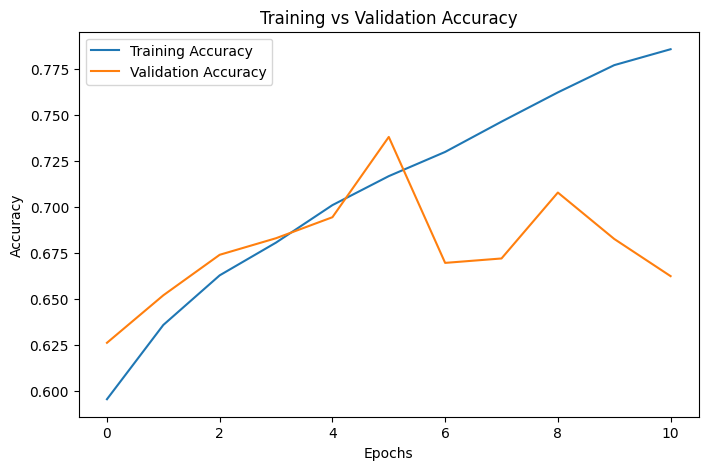

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

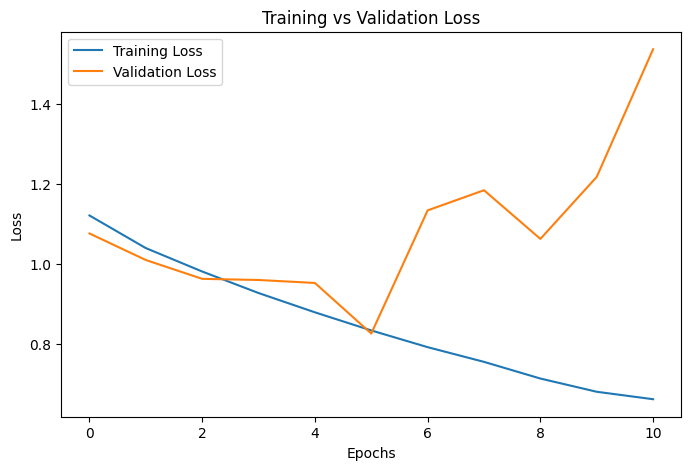

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [14]:
loss, accuracy = model.evaluate(val_data)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.7379 - loss: 0.8269
Validation Loss: 0.8268576860427856
Validation Accuracy: 0.737895131111145


In [15]:
from tensorflow.keras.models import load_model

best_model = load_model("/content/best_cat_dog_basic_cnn_overfitting_solution.h5")

print("Best model loaded successfully.")

Best model loaded successfully.


Saving cat1.jpg to cat1 (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


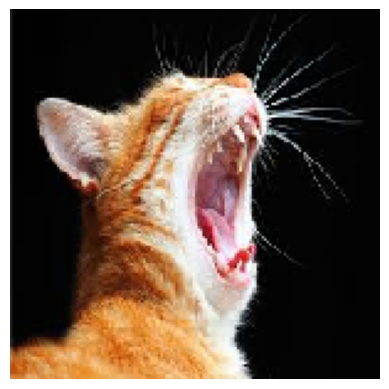

Prediction: Cat
Confidence: 0.6841604113578796


In [19]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np

uploaded = files.upload()

for file_name in uploaded.keys():
    img_path = file_name

    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = best_model.predict(img_array)

    plt.imshow(img)
    plt.axis("off")
    plt.show()

    if prediction[0][0] > 0.5:
        print("Prediction: Dog")
        print("Confidence:", float(prediction[0][0]))
    else:
        print("Prediction: Cat")
        print("Confidence:", float(1 - prediction[0][0]))